In [17]:
import os, sys
import os
import sys
import pandas as pd

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.optimization import build_return_cov, optimize_max_sharpe, optimize_min_vol


# Load price histories
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_bnd  = pd.read_csv("../data/processed/bnd_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_spy  = pd.read_csv("../data/processed/spy_cleaned.csv", parse_dates=["Date"], index_col="Date")

# Ensure numeric dtype for Close columns
for df in [df_tsla, df_bnd, df_spy]:
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

# Drop any rows with NaNs after conversion
df_tsla.dropna(subset=["Close"], inplace=True)
df_bnd.dropna(subset=["Close"], inplace=True)
df_spy.dropna(subset=["Close"], inplace=True)

# Build price dataframe
price_df = pd.concat([df_tsla["Close"], df_bnd["Close"], df_spy["Close"]], axis=1)
price_df.columns = ["TSLA","BND","SPY"]

# Forecast implied expected return (annualized)
future_series = df_tsla["Close"]
tsla_expected_return = future_series.pct_change().mean() * 252

# Now safe to call build_return_cov
mu, cov = build_return_cov(price_df, tsla_expected_return)
weights_sharpe, perf_sharpe = optimize_max_sharpe(mu, cov)
weights_minvol, perf_minvol = optimize_min_vol(mu, cov)

print("Max Sharpe weights:", weights_sharpe)
print("Max Sharpe performance:", perf_sharpe)
print("Min Vol weights:", weights_minvol)
print("Min Vol performance:", perf_minvol)


# Add project root for src imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.backtesting import cumulative_returns, performance_metrics
import pandas as pd

# Recreate price_df and returns
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_bnd  = pd.read_csv("../data/processed/bnd_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_spy  = pd.read_csv("../data/processed/spy_cleaned.csv", parse_dates=["Date"], index_col="Date")

df_tsla["Close"] = pd.to_numeric(df_tsla["Close"], errors="coerce")
df_bnd["Close"]  = pd.to_numeric(df_bnd["Close"], errors="coerce")
df_spy["Close"]  = pd.to_numeric(df_spy["Close"], errors="coerce")

df_tsla.dropna(subset=["Close"], inplace=True)
df_bnd.dropna(subset=["Close"], inplace=True)
df_spy.dropna(subset=["Close"], inplace=True)

price_df = pd.concat([
    df_tsla["Close"],
    df_bnd["Close"],
    df_spy["Close"]
], axis=1)
price_df.columns = ["TSLA", "BND", "SPY"]

rets = price_df.pct_change().dropna()

# Backtesting window
start_bt="2025-01-01"
end_bt  ="2026-01-15"
bt_rets = rets.loc[start_bt:end_bt]




Expected annual return: 10.6%
Annual volatility: 11.0%
Sharpe Ratio: 0.96
Expected annual return: 2.6%
Annual volatility: 5.3%
Sharpe Ratio: 0.49
Max Sharpe weights: OrderedDict({'TSLA': 0.11746, 'BND': 0.59679, 'SPY': 0.28575})
Max Sharpe performance: (np.float64(0.10592033604383973), np.float64(0.11017546962864348), np.float64(0.9613785754746853))
Min Vol weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94272, 'SPY': 0.05728})
Min Vol performance: (np.float64(0.025835211649157832), np.float64(0.05256541639521539), np.float64(0.49148686381393153))


In [13]:
w = weights_sharpe
cum_strat = cumulative_returns(w, bt_rets)

# 60/40 benchmark
bench_rets = 0.6*bt_rets["SPY"] + 0.4*bt_rets["BND"]
cum_bench = (1 + bench_rets).cumprod()


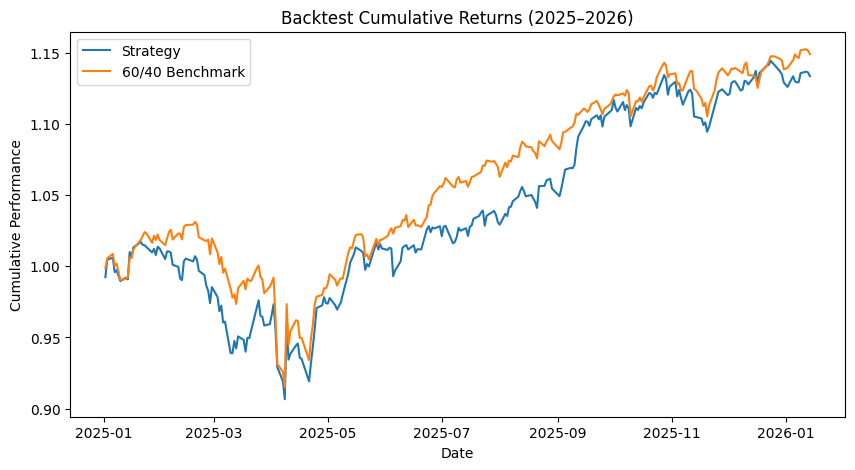

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cum_strat, label="Strategy")
plt.plot(cum_bench, label="60/40 Benchmark")
plt.title("Backtest Cumulative Returns (2025–2026)")
plt.xlabel("Date")
plt.ylabel("Cumulative Performance")
plt.legend()
plt.show()


In [19]:
import numpy as np

def performance_metrics(cumrets):
    total_return = cumrets.iloc[-1] - 1
    daily_returns = cumrets.pct_change().dropna()
    # Annualized return using 252 trading days
    annualized = (1 + daily_returns.mean())**252 - 1
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    max_dd = (cumrets.cummax() - cumrets).max()
    return {
        "Total Return": total_return,
        "Annualized Return": annualized,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_dd
    }

strat_perf = performance_metrics(cum_strat)
bench_perf = performance_metrics(cum_bench)

print("Strategy Performance:", strat_perf)
print("Benchmark Performance:", bench_perf)


Strategy Performance: {'Total Return': np.float64(0.13369479128068584), 'Annualized Return': np.float64(0.14733081452853614), 'Sharpe Ratio': np.float64(1.1222103140036135), 'Max Drawdown': np.float64(0.1105467955729319)}
Benchmark Performance: {'Total Return': np.float64(0.14920839310209022), 'Annualized Return': np.float64(0.15490579602573984), 'Sharpe Ratio': np.float64(1.2189690409791478), 'Max Drawdown': np.float64(0.11642620520316282)}
